<a href="https://colab.research.google.com/github/springboardmentor1/agritield-predictor/blob/Mangesh/Agriyield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Database/dataset.csv')

In [3]:
print("Dataset Head:\n", df.head())
print("\nDataset Info:\n")
df.info()

Dataset Head:
             State       Crop Soil_Type Fertilizer    N   P    K  Rainfall_mm  \
0       Karnataka    Soybean     Loamy        DAP   96  41   51          123   
1          Odisha     Cotton  Red Soil       Urea   29  36  112          247   
2          Punjab  Groundnut  Red Soil    Compost   37  38  177          142   
3         Gujarat      Wheat  Red Soil    Compost   58  77  129          227   
4  Andhra Pradesh     Cotton      Clay    Organic  108  61   63          263   

   Temperature_C  Yield_kg_per_acre  Soil_pH  Year  
0          31.06               1899     6.82  2003  
1          33.97               1002     6.41  2002  
2          24.21               1465     7.06  2015  
3          30.85               2273     5.93  2022  
4          37.81               1497     6.24  2017  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------    

In [4]:
df = df.dropna()

In [5]:
categorical_cols = ['State', 'Crop', 'Soil_Type', 'Fertilizer']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [6]:
X = df.drop(columns=['Yield_kg_per_acre', 'Year']) # Dropping Year as it's often a sequence index
y = df['Yield_kg_per_acre']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
print("\nPreprocessing Complete.")
print(f"Training set size: {X_train_scaled.shape}")
print(f"Testing set size: {X_test_scaled.shape}")


Preprocessing Complete.
Training set size: (1200, 10)
Testing set size: (300, 10)


In [10]:
processed_df = pd.DataFrame(X_train_scaled, columns=X.columns)
processed_df['Yield'] = y_train.values
processed_df.to_csv('preprocessed_dataset.csv', index=False)

In [11]:
sns.set_theme(style="whitegrid")

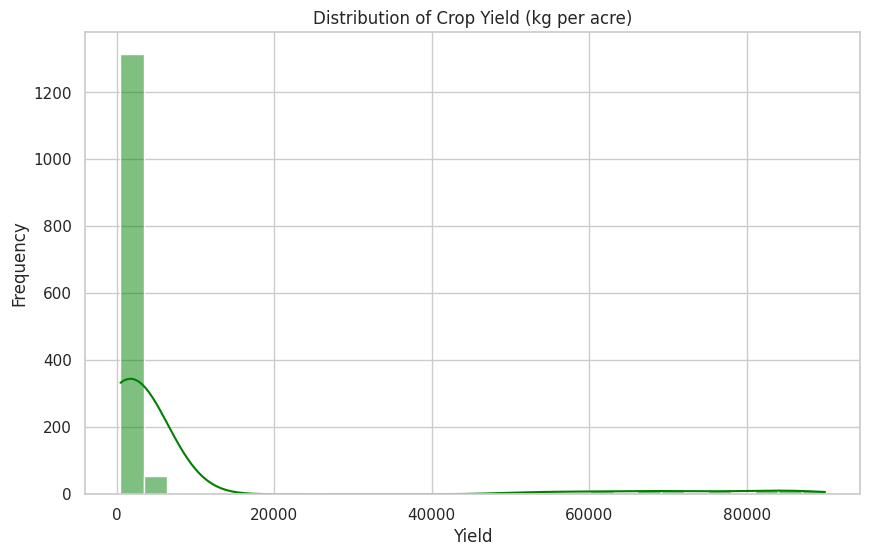

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Yield_kg_per_acre'], kde=True, bins=30, color='green')
plt.title('Distribution of Crop Yield (kg per acre)')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.savefig('yield_distribution.png')

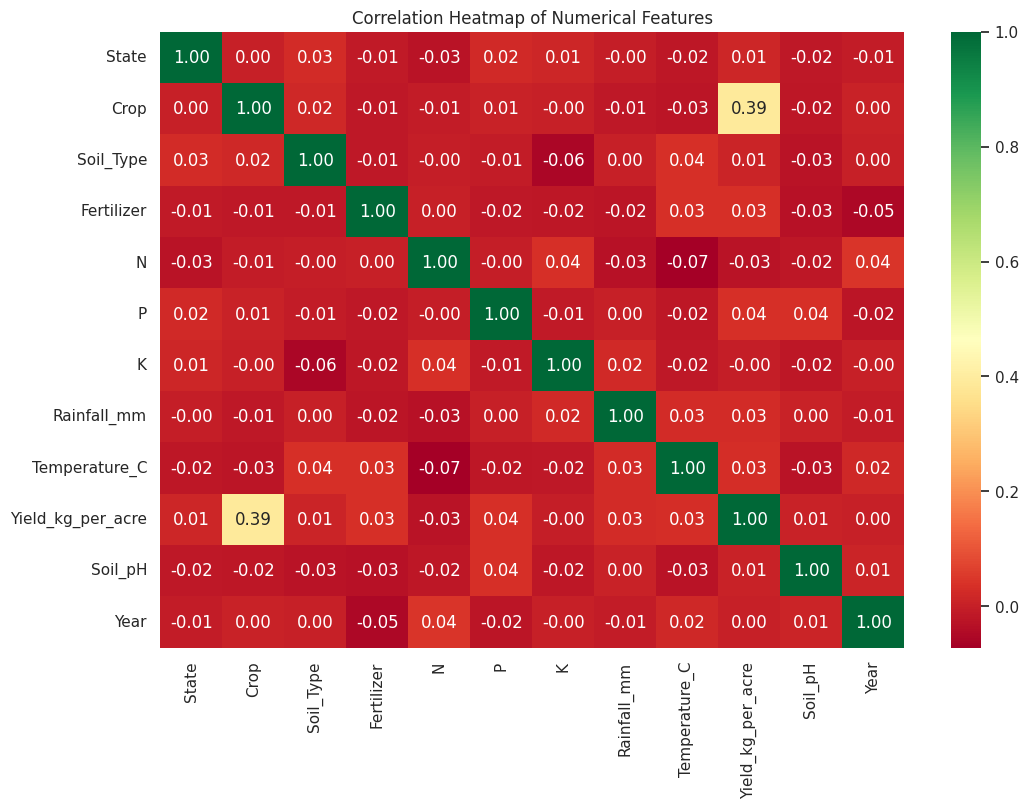

In [13]:
plt.figure(figsize=(12, 8))
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('correlation_heatmap.png')

/tmp/ipykernel_313/323803072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_yield.index, y=crop_yield.values, palette='viridis')


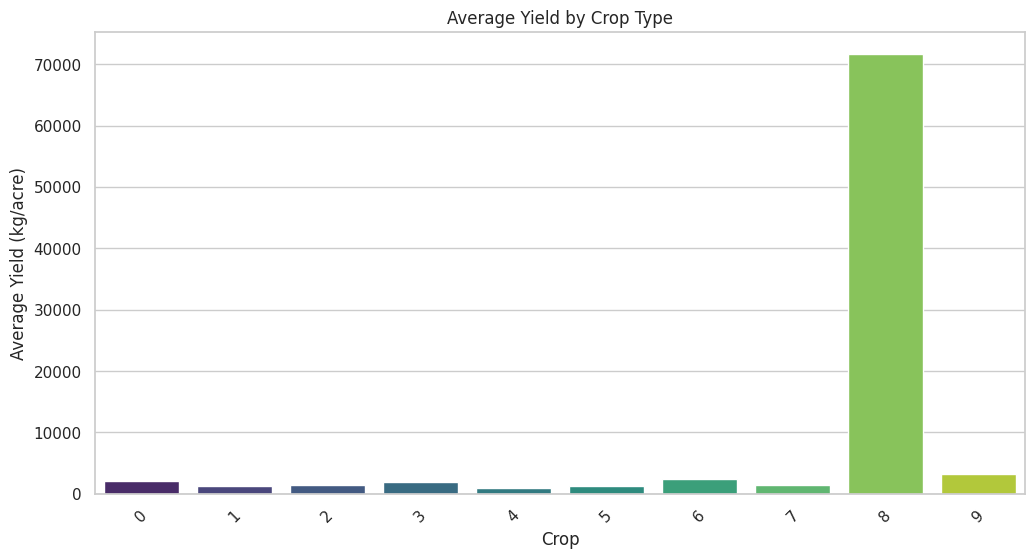

In [14]:
plt.figure(figsize=(12, 6))
crop_yield = df.groupby('Crop')['Yield_kg_per_acre'].mean().sort_values(ascending=False)
sns.barplot(x=crop_yield.index, y=crop_yield.values, palette='viridis')
plt.title('Average Yield by Crop Type')
plt.xticks(rotation=45)
plt.ylabel('Average Yield (kg/acre)')
plt.savefig('avg_yield_by_crop.png')

/tmp/ipykernel_313/3096889222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Soil_Type', y='Yield_kg_per_acre', data=df, palette='Set2')


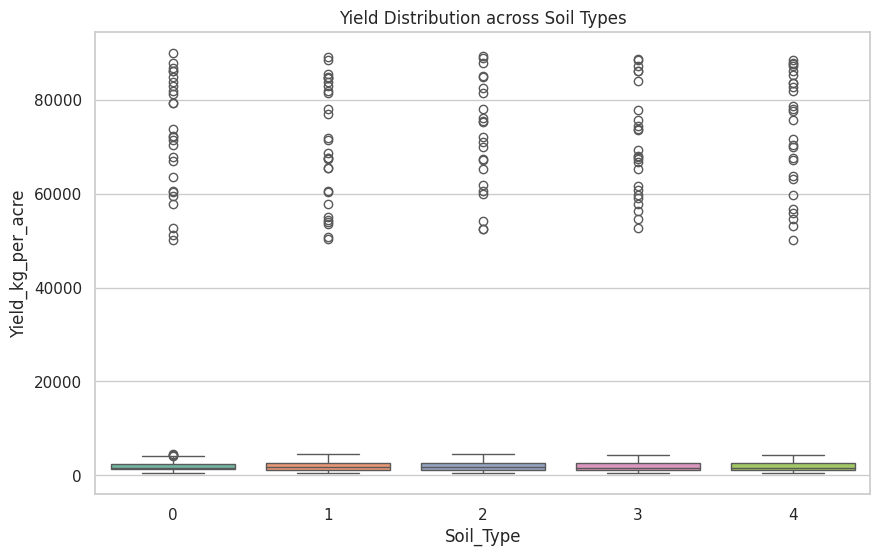

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Soil_Type', y='Yield_kg_per_acre', data=df, palette='Set2')
plt.title('Yield Distribution across Soil Types')
plt.savefig('yield_by_soil.png')

**Milestone 2**

In [16]:
df['Total_Nutrients'] = df['N'] + df['P'] + df['K']

In [17]:
df['Temp_Rainfall_Interaction'] = df['Temperature_C'] * df['Rainfall_mm']

In [18]:
df['Heat_Stress'] = df['Temperature_C'].apply(lambda x: 1 if x > 35 else 0)

In [19]:
df['pH_Deviation'] = abs(df['Soil_pH'] - 6.5)

In [20]:
categorical_cols = ['State', 'Crop', 'Soil_Type', 'Fertilizer']
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_Encoded'] = le.fit_transform(df[col])

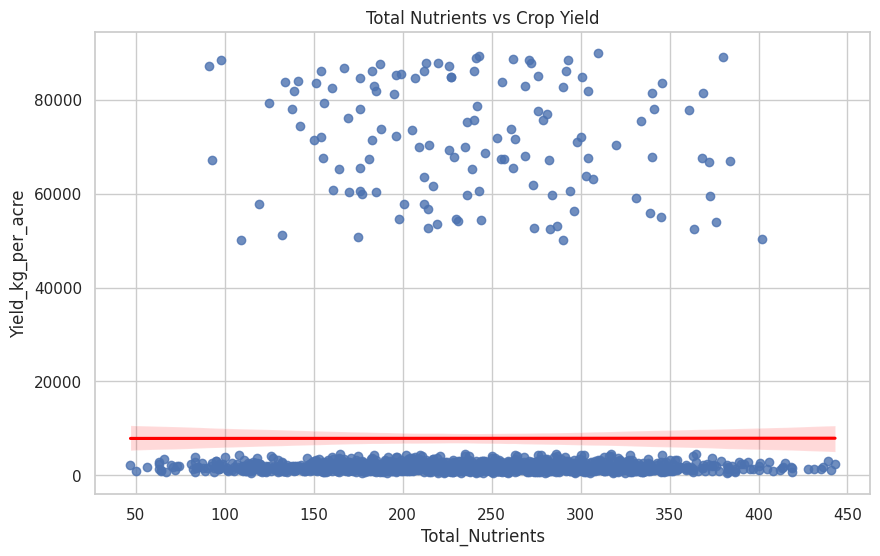

In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Total_Nutrients', y='Yield_kg_per_acre', data=df,
            scatter_kws={'alpha':0.8}, line_kws={'color':'red'})
plt.title('Total Nutrients vs Crop Yield')
plt.savefig('nutrients_vs_yield.png')

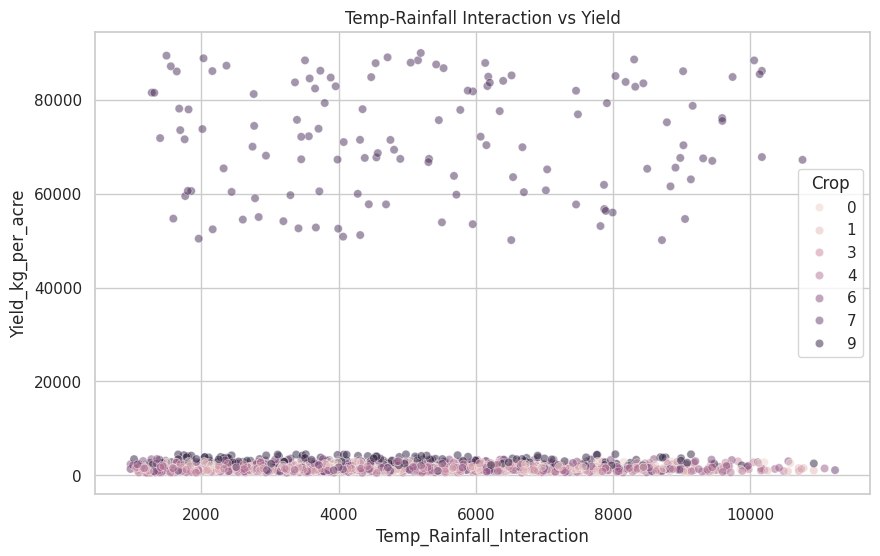

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temp_Rainfall_Interaction', y='Yield_kg_per_acre',
                hue='Crop', data=df, alpha=0.5)
plt.title('Temp-Rainfall Interaction vs Yield')
plt.savefig('interaction_vs_yield.png')

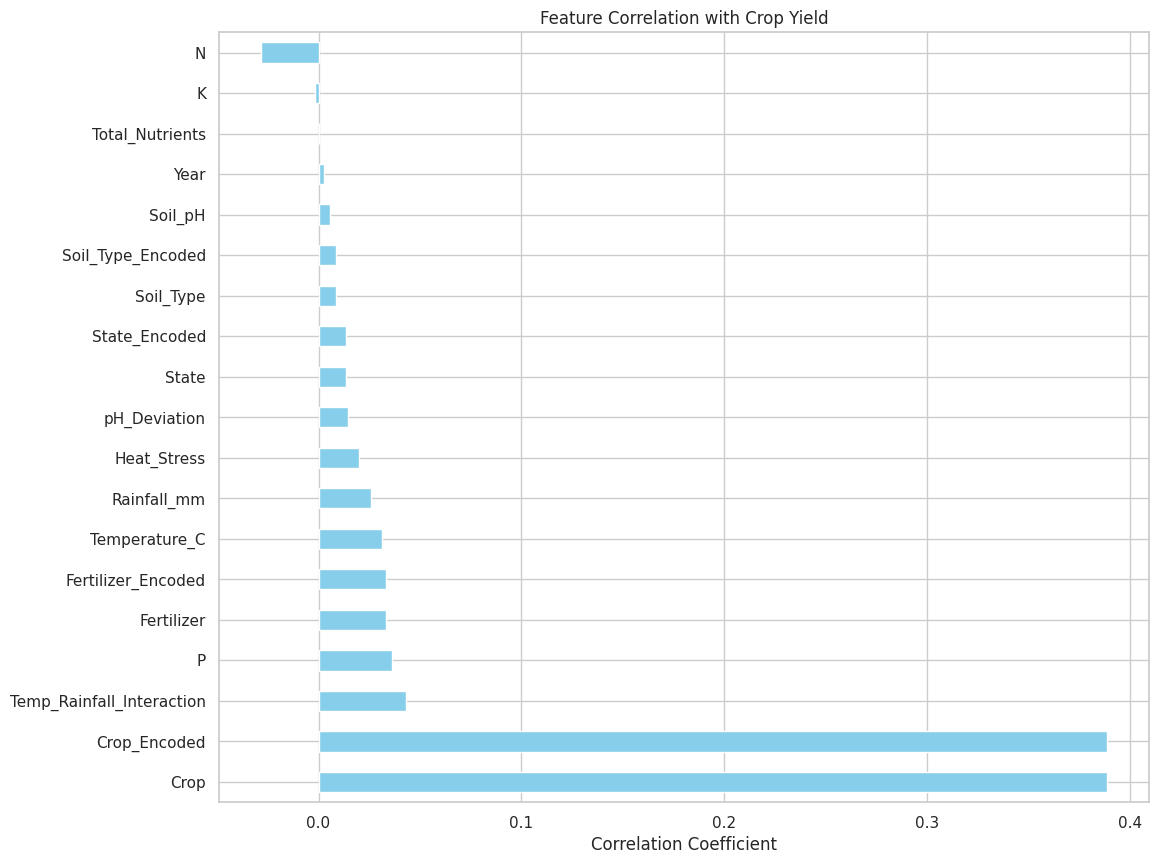

In [23]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Yield_kg_per_acre'].sort_values(ascending=False)
correlations.drop('Yield_kg_per_acre').plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Crop Yield')
plt.xlabel('Correlation Coefficient')
plt.savefig('feature_importance_correlation.png')

In [24]:
df.to_csv('engineered_dataset.csv', index=False)